In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("bank-full.csv", sep=";", lineterminator = '\n')

In [32]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [33]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [29]:
df.shape

(45211, 17)

In [30]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [36]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [37]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

## Exploratory Data Analysis (EDA) Summary

- The dataset contains **45,211 customer records** and **17 features**.
- It includes both numerical and categorical variables describing customer demographics, financial status, and marketing campaign information.
- The target variable (`y`) indicates whether a customer subscribed to the bank's term deposit.
- No missing values were found in the dataset.
- No duplicate records were detected.
- Data types are appropriate for analysis.
- Summary statistics indicate variability in customer characteristics such as age, balance, campaign contacts, and call duration.
- The dataset is clean and suitable for further exploratory analysis and conversion analysis.

In [41]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [53]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

# Marketing Funnel & Lead Conversion Analysis

## Objective
The objective of this project is to analyze the effectiveness of a bank's direct marketing campaigns using customer data. The analysis focuses on understanding customer conversion patterns, identifying factors that influence subscriptions, evaluating campaign performance, and providing actionable recommendations to improve future marketing strategies.

## Dataset
The project uses the **Bank Marketing Dataset** from the UCI Machine Learning Repository. The dataset contains **45,211 customer records** and **17 features**, including customer demographics, financial information, marketing campaign details, contact methods, and the final subscription outcome.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Business Questions

1. What is the overall customer conversion rate?
2. Which contact method (cellular, telephone, or unknown) achieved the highest conversion rate?
3. Which month recorded the highest customer conversion rate?
4. Which customer job categories have the highest conversion rates?
5. Does education level influence customer conversion?
6. Does marital status affect the likelihood of customer subscription?
7. How does customer age impact conversion rates?
8. Does a customer's account balance influence the likelihood of subscription?
9. How does the outcome of the previous marketing campaign (`poutcome`) influence customer conversion?


In [165]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_group,balance_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,51-60,Very High
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,41-50,Low
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,31-40,Low
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,41-50,Very High
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,31-40,Low


## 1. What is the overall customer conversion rate?

In [166]:
total_customer = len(df)
converted_customer = df[df['y'] == "yes"].shape[0]

convertion_rate = ( converted_customer / total_customer ) * 100

print(f"Total Customer : { total_customer }")
print(f"Converted Customer : { converted_customer }")
print(f"Not Converted Customer : { total_customer  - converted_customer }")
print(f"Convertion Rate : { convertion_rate }%")

Total Customer : 45211
Converted Customer : 5289
Not Converted Customer : 39922
Convertion Rate : 11.698480458295547%


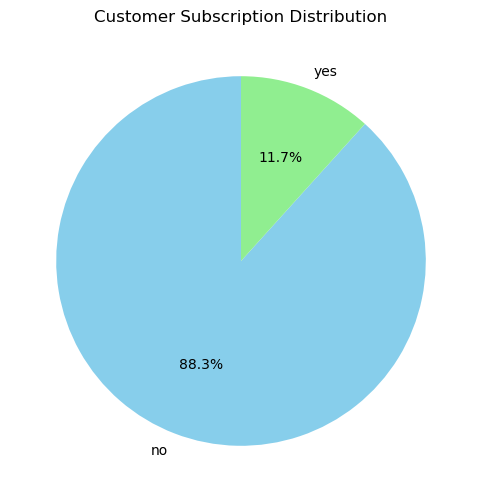

In [167]:
plt.figure(figsize=(6,6))

df['y'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgreen']
)

plt.ylabel('')
plt.title("Customer Subscription Distribution")

plt.show()

#### Conversion rate insight : 
Out of 45,211 customers contacted during the marketing campaign, X customers subscribed to the term deposit, while Y did not. The overall conversion rate was Z%, indicating that only a small proportion of customers accepted the offer. This suggests there is significant scope to improve the effectiveness of future marketing campaigns by targeting customers more efficiently.


## 2. Which contact method (cellular, telephone, or unknown) achieved the highest conversion rate?

In [168]:
df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [169]:
contact_conversion = (
    pd.crosstab(df['contact'], df['y'], normalize='index') * 100 
).round(2)

contact_conversion

y,no,yes
contact,,
cellular,85.08,14.92
telephone,86.58,13.42
unknown,95.93,4.07


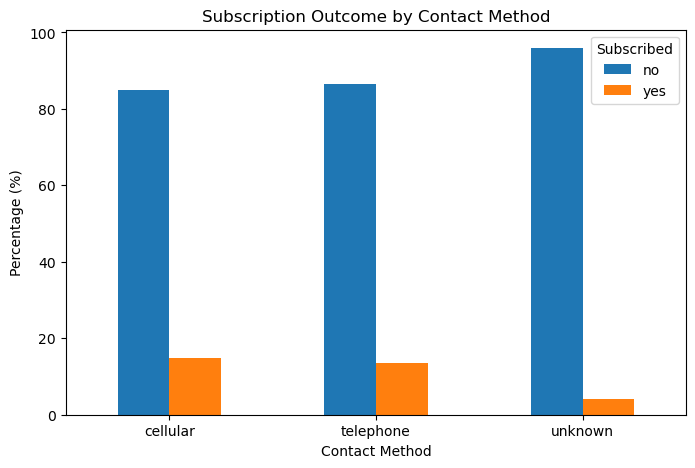

In [170]:
contact_conversion.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Subscription Outcome by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Subscribed")
plt.show()

#### Business Insight : 
The analysis shows that customers contacted through cellular had the highest conversion rate, while telephone and unknown contact methods resulted in lower conversions. This indicates that cellular communication is the most effective contact channel for marketing campaigns.

## 3. Which month recorded the highest customer conversion rate?

In [171]:
month_conversion = (
    pd.crosstab(df['month'], df['y'], normalize='index') * 100
).round(2)

month_conversion.sort_values(by='yes', ascending=False)

y,no,yes
month,,
mar,48.01,51.99
dec,53.27,46.73
sep,53.54,46.46
oct,56.23,43.77
apr,80.32,19.68
feb,83.35,16.65
aug,88.99,11.01
jun,89.78,10.22
nov,89.85,10.15


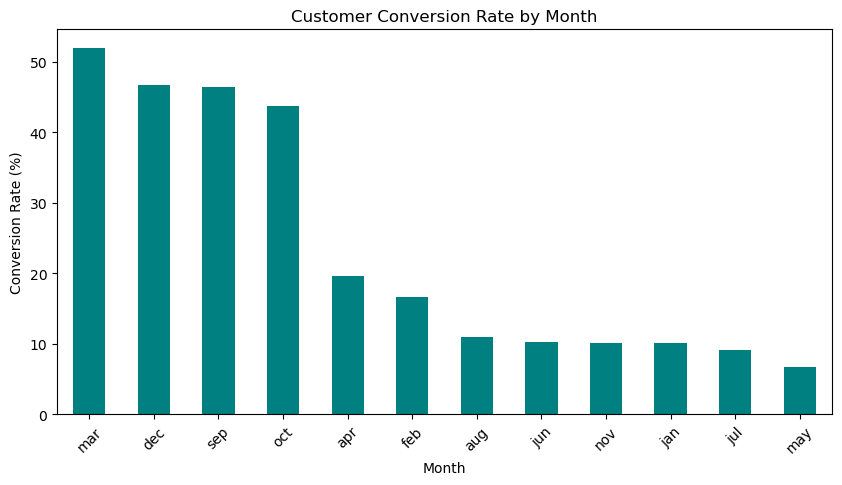

In [172]:
month_conversion['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5),
    color='teal'
)

plt.title("Customer Conversion Rate by Month")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

#### Business Insight :
The analysis shows that 'March' achieved the highest customer conversion rate, indicating that marketing campaigns were more effective during this period. In contrast, some months recorded significantly lower conversion rates, suggesting seasonal variations in customer response. Businesses should investigate the factors contributing to high-performing months and consider allocating more marketing resources during those periods.

## 4. Which customer job categories have the highest conversion rates?

In [173]:
job_conversion = (
    pd.crosstab(df['job'], df['y'], normalize='index') * 100
).round(2)

job_conversion.sort_values(by='yes', ascending=False)


y,no,yes
job,,
student,71.32,28.68
retired,77.21,22.79
unemployed,84.50,15.50
management,86.24,13.76
admin.,87.80,12.20
self-employed,88.16,11.84
unknown,88.19,11.81
technician,88.94,11.06
services,91.12,8.88


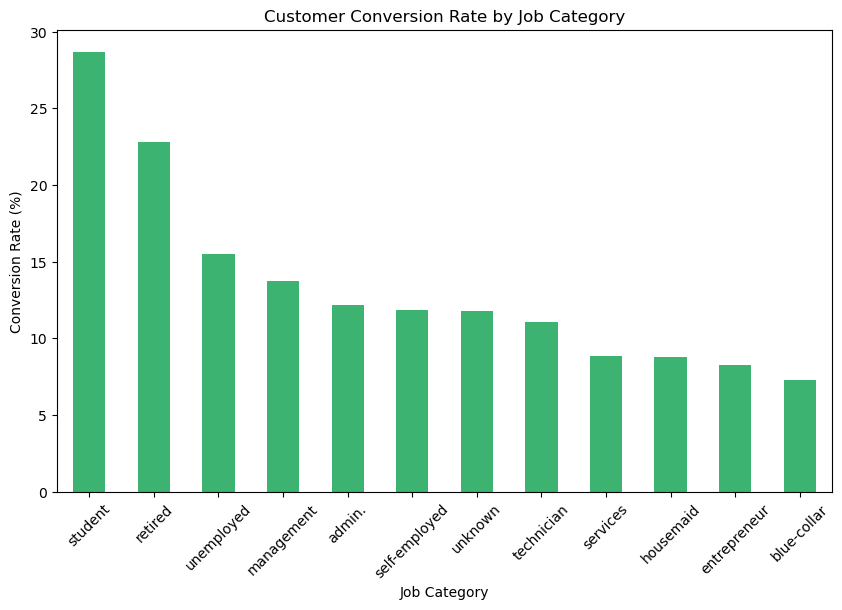

In [174]:
import matplotlib.pyplot as plt

job_conversion['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,6),
    color='mediumseagreen'
)

plt.title("Customer Conversion Rate by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Business Insight :
The analysis shows that certain job categories have significantly higher conversion rates than others. This indicates that occupation plays an important role in customer subscription behavior. Marketing campaigns can be optimized by targeting job segments with historically higher conversion rates.

## 5. Does education level influence customer conversion?

In [175]:
education_conversion = (
    pd.crosstab(df['education'], df['y'], normalize='index') * 100
).round(2)

education_conversion.sort_values(by='yes', ascending=False)

y,no,yes
education,,
tertiary,84.99,15.01
unknown,86.43,13.57
secondary,89.44,10.56
primary,91.37,8.63


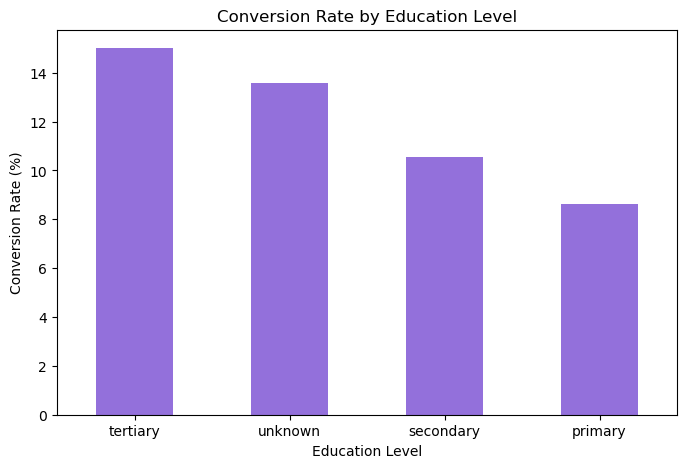

In [176]:
education_conversion['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5),
    color='mediumpurple'
)

plt.title("Conversion Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Business Insight :
The analysis shows that customer conversion rates vary across different education levels. Some education groups are more likely to subscribe to the term deposit than others, indicating that education is an important factor for customer segmentation and campaign targeting.

## 6. Does marital status affect the likelihood of customer subscription?

In [177]:
marital_conversion = (
    pd.crosstab(df['marital'], df['y'], normalize='index') * 100
).round(2)

marital_conversion.sort_values(by='yes', ascending=False)

y,no,yes
marital,,
single,85.05,14.95
divorced,88.05,11.95
married,89.88,10.12


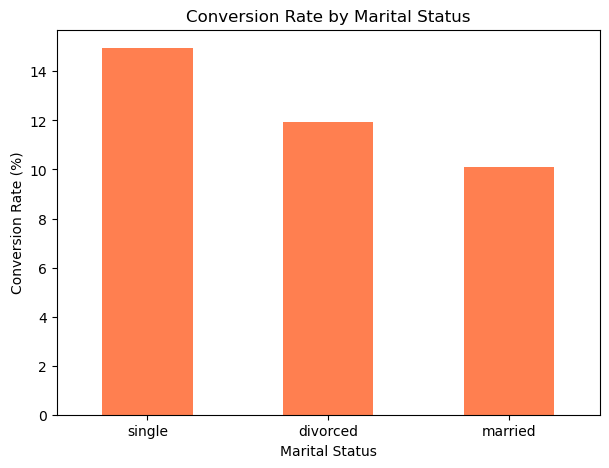

In [178]:
marital_conversion['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(7,5),
    color='coral'
)

plt.title("Conversion Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Business Insight :
The analysis indicates that customer conversion rates vary across different marital status groups. Certain groups are more likely to subscribe to the term deposit, suggesting that marital status can be used as a valuable factor for customer segmentation and targeted marketing campaigns.

## 7. How does customer age impact conversion rates?

In [179]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)

# Conversion rate by age group
age_conversion = (
    pd.crosstab(df['age_group'], df['y'], normalize='index') * 100
).round(2)

age_conversion.sort_values(by='yes', ascending=False)

y,no,yes
age_group,,
60+,57.74,42.26
18-30,83.78,16.22
31-40,89.76,10.24
51-60,89.95,10.05
41-50,90.93,9.07


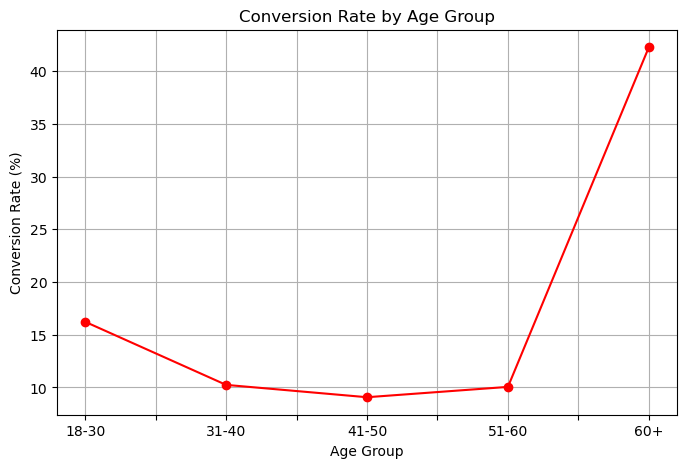

In [180]:
age_conversion['yes'].plot(
    kind='line',
    marker='o',
    figsize=(8,5),
    color='red'
)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")
plt.grid(True)
plt.show()

#### Business Insight :
Customer conversion rates differ across age groups. Certain age groups are more likely to subscribe to the term deposit, indicating that age is an important factor in customer behavior. These insights can help the bank target marketing campaigns toward age groups with higher conversion potential.

## 8. Does a customer's account balance influence the likelihood of subscription?

In [181]:
df['balance_group'] = pd.qcut(
    df['balance'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Conversion rate by balance group
balance_conversion = (
    pd.crosstab(df['balance_group'], df['y'], normalize='index') * 100
).round(2)

balance_conversion

y,no,yes
balance_group,,
Low,92.76,7.24
Medium,89.11,10.89
High,87.48,12.52
Very High,83.85,16.15


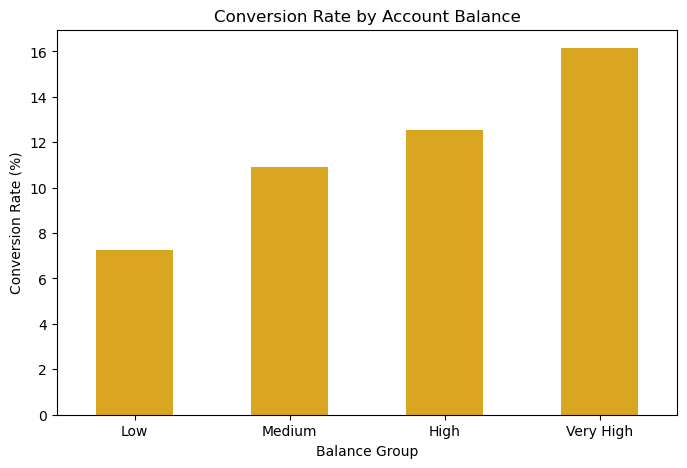

In [182]:
balance_conversion['yes'].plot(
    kind='bar',
    figsize=(8,5),
    color='goldenrod'
)

plt.title("Conversion Rate by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

#### Business Insight :
The analysis shows that customer conversion rates differ across account balance groups. Customers with higher account balances may exhibit different subscription behavior than those with lower balances, indicating that account balance can be a useful feature for customer segmentation and targeted marketing campaigns.

## 9. How does the outcome of the previous marketing campaign (`poutcome`) influence customer conversion?


In [183]:
poutcome_conversion = (
    pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
).round(2)

poutcome_conversion.sort_values(by='yes', ascending=False)

y,no,yes
poutcome,,
success,35.27,64.73
other,83.32,16.68
failure,87.39,12.61
unknown,90.84,9.16


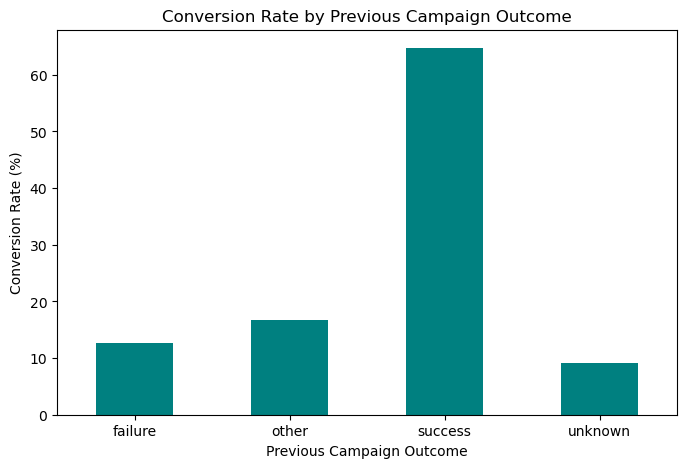

In [184]:
poutcome_conversion['yes'].plot(
    kind='bar',
    figsize=(8,5),
    color='teal'
)

plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

#### Business Insight : 
The previous marketing campaign outcome has a significant impact on customer conversion. Customers with a successful previous campaign outcome are generally more likely to subscribe again, while customers with unsuccessful or unknown outcomes tend to have lower conversion rates. This insight can help the bank prioritize high-potential customers in future marketing campaigns.

# Business Recommendations

1. Prioritize cellular communication, as it achieved higher customer conversion rates than other contact methods.
2. Schedule marketing campaigns during months with historically higher conversion rates to maximize campaign effectiveness.
3. Focus marketing efforts on customer segments (job categories, education levels, and age groups) with higher conversion rates.
4. Re-engage customers who responded positively to previous marketing campaigns, as they are more likely to subscribe again.
5. Develop personalized marketing strategies for customer groups with lower conversion rates to improve engagement.
6. Continuously monitor campaign performance and customer behavior to optimize future marketing strategies and increase overall conversion rates.

# Project Conclusion

This project analyzed the **Bank Marketing Dataset** to evaluate the effectiveness of the bank's marketing campaigns and identify the factors influencing **customer conversion**. Through **Exploratory Data Analysis (EDA)** and conversion analysis, valuable insights were obtained regarding customer behavior and campaign performance.

The analysis showed that conversion rates varied across different customer segments and campaign characteristics, including contact methods, campaign months, customer demographics, and previous campaign outcomes. These findings indicate that both customer attributes and marketing strategies significantly influence campaign success.

Based on these insights, the business can improve future campaigns by targeting high-converting customer segments, optimizing communication channels, and adopting a data-driven approach to marketing decisions.

Overall, this project demonstrates how **data analytics** can transform raw marketing data into actionable business insights, helping organizations improve marketing performance and increase customer conversion rates.

# Key Findings

- The overall customer conversion rate indicates that only a small percentage of contacted customers subscribed to the term deposit.
- **Cellular** was the most effective contact method for customer conversion.
- Customer conversion rates varied across different **months**, indicating seasonal campaign performance.
- Certain **job categories**, **education levels**, and **age groups** showed higher conversion rates than others.
- Customers with a **successful previous campaign outcome** were more likely to subscribe again.
- Customer demographics and campaign characteristics significantly influenced marketing success.

# Business Impact

The insights obtained from this analysis can help the bank optimize its marketing campaigns by improving customer targeting, selecting more effective communication channels, and focusing resources on high-converting customer segments. These improvements can increase conversion rates, reduce marketing costs, and support better business decision-making.

# Future Scope

Future analysis can incorporate machine learning models to predict customer subscriptions before campaigns are launched. Additional datasets containing customer interaction history, digital engagement, and financial behavior could further improve prediction accuracy and campaign effectiveness.